<a href="https://colab.research.google.com/github/MahediMRifat/Depression-prediction-ml/blob/main/Depression_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


file_path = '/content/drive/MyDrive/CSE422 Lab/Depression Data - Depression Data.csv'


df = pd.read_csv(file_path)


df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,1. Age,2. Gender,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 37 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                                                                                 --------------  ----- 
 0   1. Age                                                                                                                                                                 1977 non-null   object
 1   2. Gender                                                                                                                                                              1971 non-null   object
 2   5. Academic Year                                                                                            

In [ ]:
df.shape

(1977, 37)

In [ ]:
df.isnull().sum()

,0
1. Age,0
2. Gender,6
5. Academic Year,0
6. Current CGPA,0
7. Did you receive a waiver or scholarship at your university?,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",0
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",0
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",0
"5. In a semester, how often have you worried too much about academic affairs?",0


In [ ]:
df['Do you have any opinion?'] = np.nan
df.head()

,1. Age,2. Gender,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?",...,"3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label,Do you have any opinion?
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,1,1,2,1,1,1,1,11,Moderate Depression,NaN
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,9,Mild Depression,NaN
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,2,3,2,2,2,2,1,16,Moderately Severe Depression,NaN
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,9,Mild Depression,NaN
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,9,Mild Depression,NaN


In [ ]:
#Adding some null values
np.random.seed(42)
mask = np.random.rand(*df.shape) < 0.05
df[mask] = np.nan
print(df.isnull().sum().head())

1. Age                                                             93
2. Gender                                                         100
5. Academic Year                                                   91
6. Current CGPA                                                   117
7. Did you receive a waiver or scholarship at your university?    104
dtype: int64


In [ ]:
df.isnull().sum()

,0
1. Age,93
2. Gender,100
5. Academic Year,91
6. Current CGPA,117
7. Did you receive a waiver or scholarship at your university?,104
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",98
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",82
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",89
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",103
"5. In a semester, how often have you worried too much about academic affairs?",88


### **Data Spliting**
#### Select and separately store Numerical and Categorical features in different variables.

In [ ]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 30 numerical features: 

['1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? ', '2. In a semester, how often have you been unable to stop worrying about your academic affairs? ', '3. In a semester, how often have you had trouble relaxing due to academic pressure? ', '4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?', '5. In a semester, how often have you worried too much about academic affairs? ', '6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?', '7. In a semester, how often have you felt afraid, as if something awful might happen?', 'Anxiety Value', '1. In a semester, how often have you felt upset due to something that happened in your academic affairs? ', '2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?', '3. In a semester, how often you felt nervous and stre

In [ ]:
#Selecting categoricalfeatures
categorical_data=df.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} numerical features:', '\n')
print(categorical_features)

There are 8 numerical features: 

['1. Age', '2. Gender', '5. Academic Year', '6. Current CGPA', '7. Did you receive a waiver or scholarship at your university?', 'Anxiety Label', 'Stress Label', 'Depression Label']


### **Descriptive Analysis**
#### In descriptive Analysis we analysis each variable separately to get inference about the feature.
### **Summary satistics of Numerical Features**

In [ ]:
# Transposed stats for numerical features

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",1879.0,1.759447,0.948422,0.0,1.0,2.0,3.0,3.0
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",1895.0,1.630607,1.026940,0.0,1.0,2.0,3.0,3.0
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",1888.0,1.739936,0.999021,0.0,1.0,2.0,3.0,3.0
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",1874.0,1.784952,0.967252,0.0,1.0,2.0,3.0,3.0
"5. In a semester, how often have you worried too much about academic affairs?",1889.0,1.863949,0.976426,0.0,1.0,2.0,3.0,3.0
"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?",1878.0,1.791800,0.987291,0.0,1.0,2.0,3.0,3.0
"7. In a semester, how often have you felt afraid, as if something awful might happen?",1888.0,1.710275,1.060572,0.0,1.0,2.0,3.0,3.0
Anxiety Value,1882.0,12.223698,5.493838,0.0,8.0,12.0,17.0,21.0
"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?",1878.0,2.351438,1.182372,0.0,2.0,2.0,3.0,4.0
"2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",1871.0,2.331374,1.146618,0.0,2.0,2.0,3.0,4.0


### **Summary satistics of Categorical features**

In [ ]:
# Transposed stats for categorical features

categorical_data.describe().T

,count,unique,top,freq
1. Age,1884,5,18-22,1211
2. Gender,1877,3,Male,1306
5. Academic Year,1886,5,First Year or Equivalent,559
6. Current CGPA,1860,6,3.00 - 3.39,538
7. Did you receive a waiver or scholarship at your university?,1873,2,No,1485
Anxiety Label,1885,4,Severe Anxiety,688
Stress Label,1871,3,Moderate Stress,1248
Depression Label,1887,6,Moderately Severe Depression,479


### **Variance of each numerical features**

In [ ]:
numerical_data.var()

,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",0.899505
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",1.054607
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0.998044
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",0.935577
"5. In a semester, how often have you worried too much about academic affairs?",0.953408
"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?",0.974744
"7. In a semester, how often have you felt afraid, as if something awful might happen?",1.124812
Anxiety Value,30.182256
"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?",1.398003
"2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",1.314732


###Skew in numerical features

In [ ]:
numerical_data.skew()

,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",-0.197924
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",-0.037568
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",-0.151347
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",-0.168831
"5. In a semester, how often have you worried too much about academic affairs?",-0.295917
"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?",-0.212415
"7. In a semester, how often have you felt afraid, as if something awful might happen?",-0.146861
Anxiety Value,-0.185339
"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?",-0.251053
"2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",-0.171227


### **Histograms and Box Plot**
#### To find the distributions and outlier in the each feature

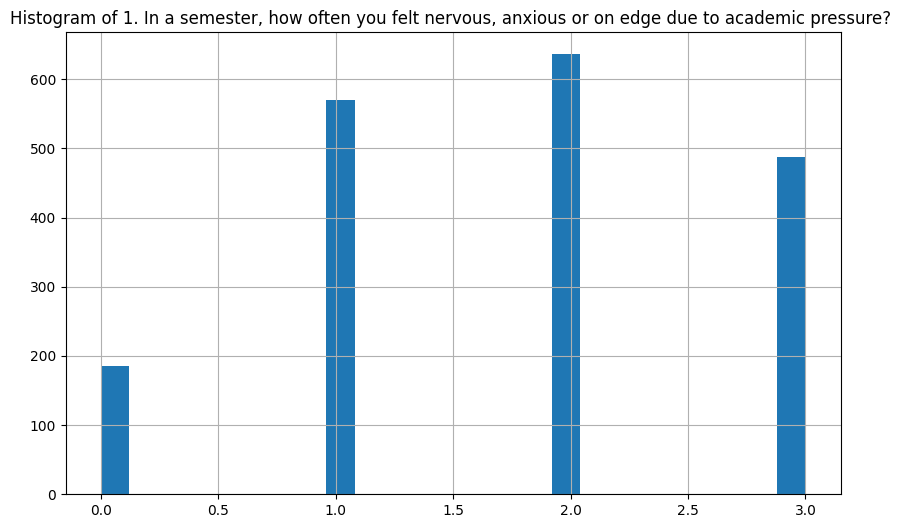

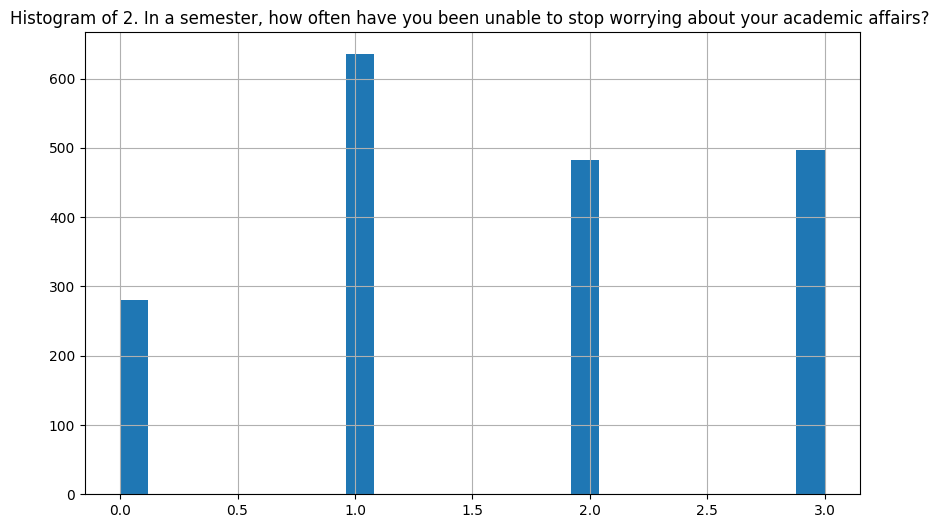

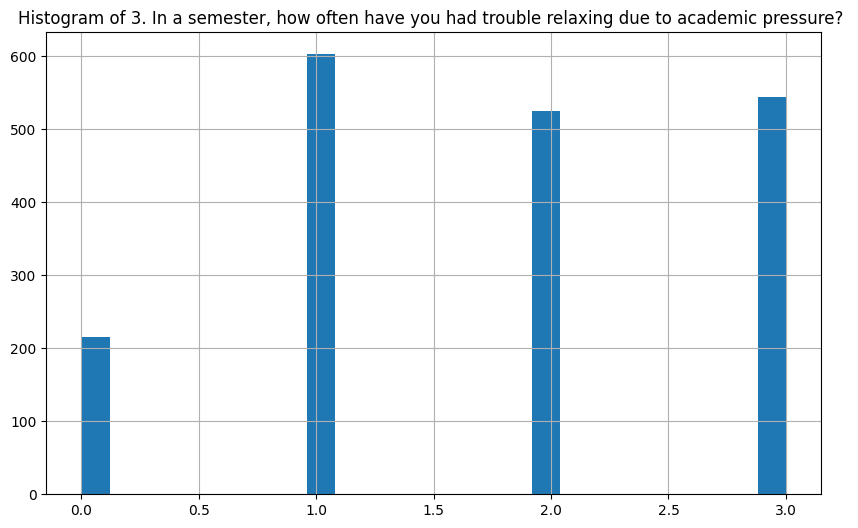

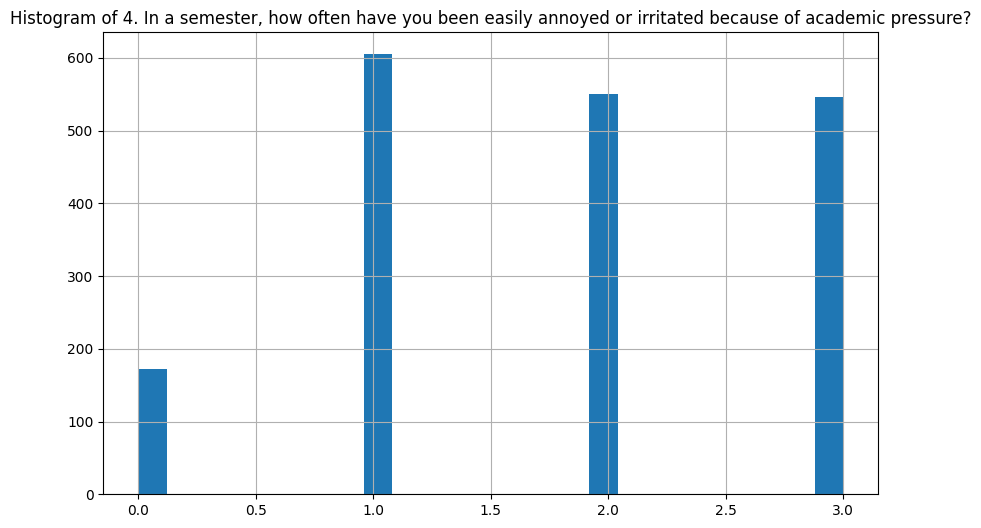

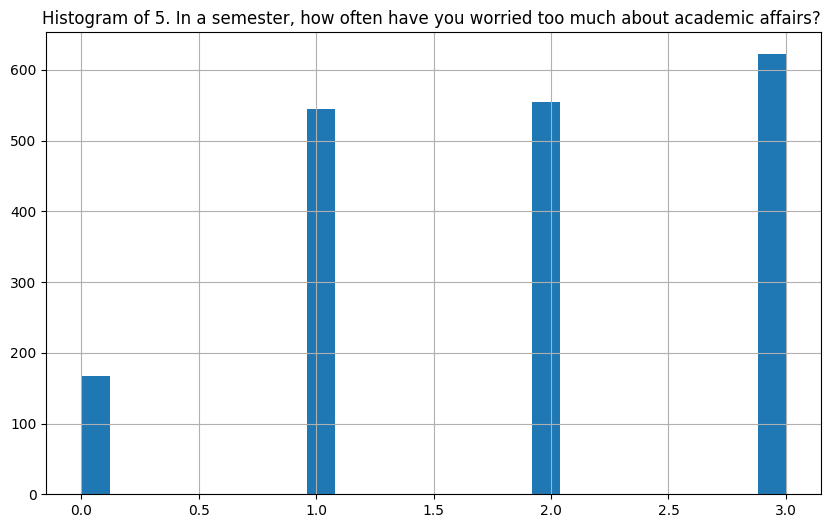

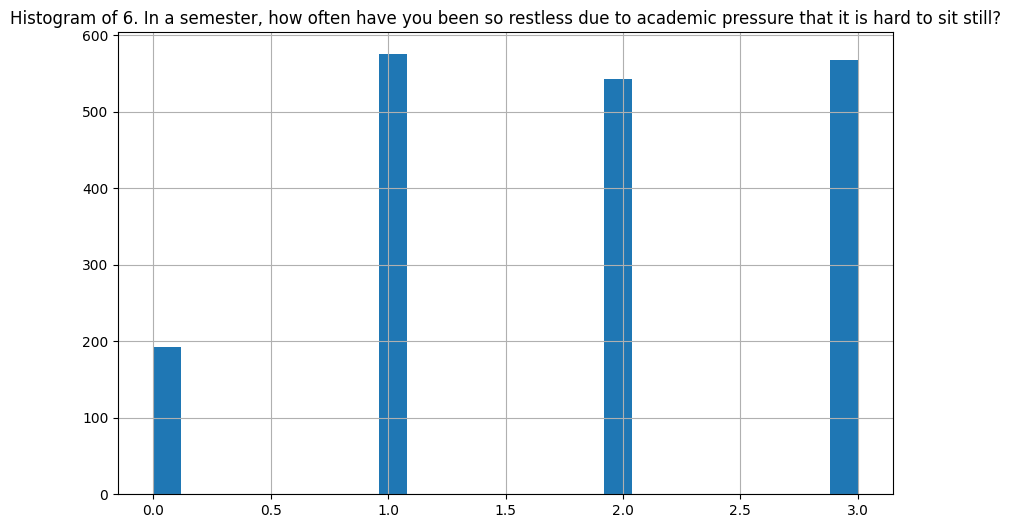

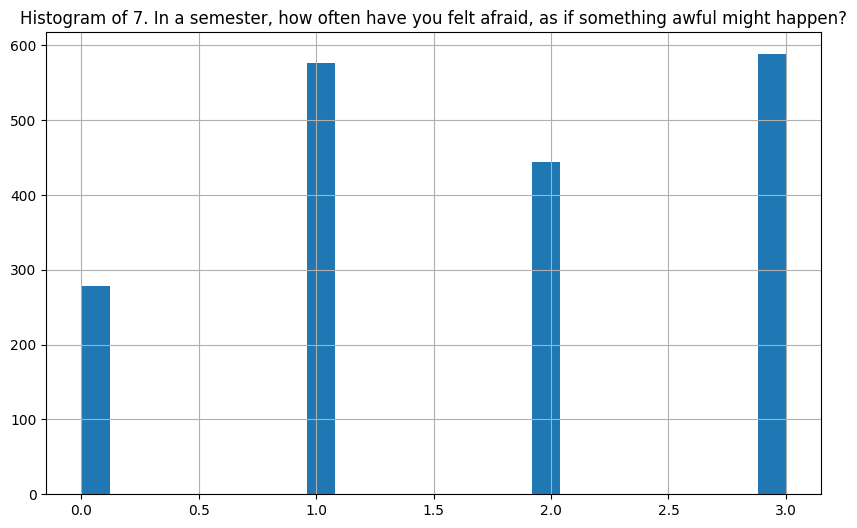

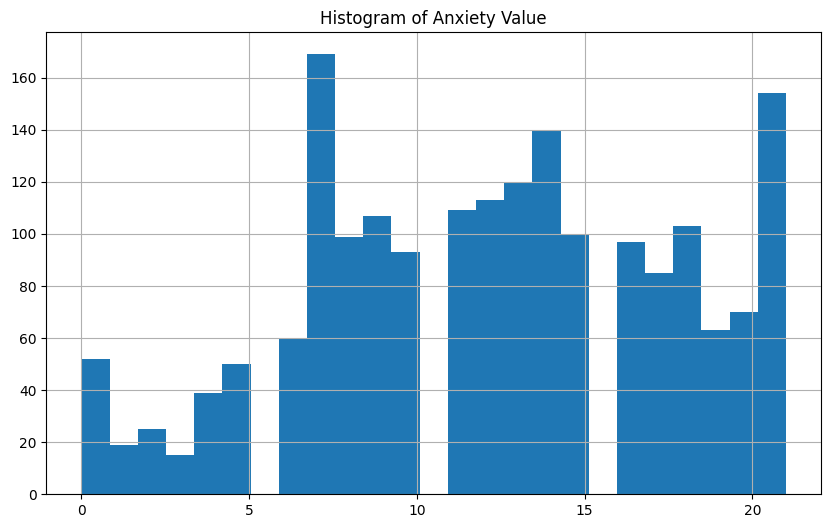

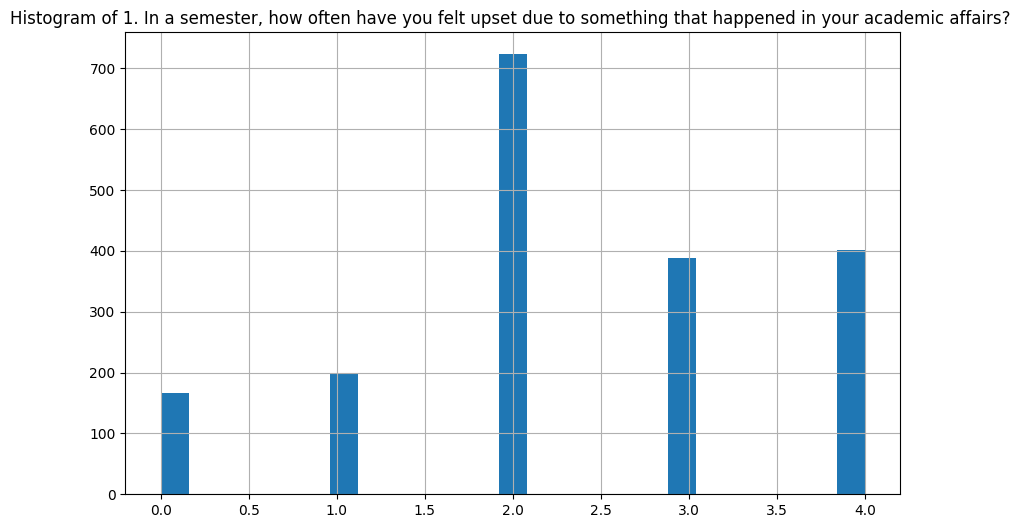

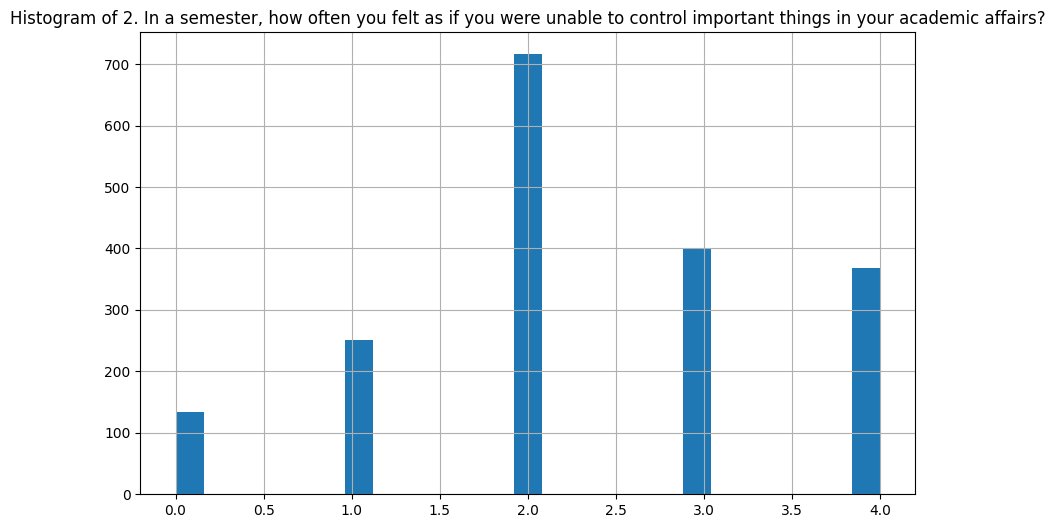

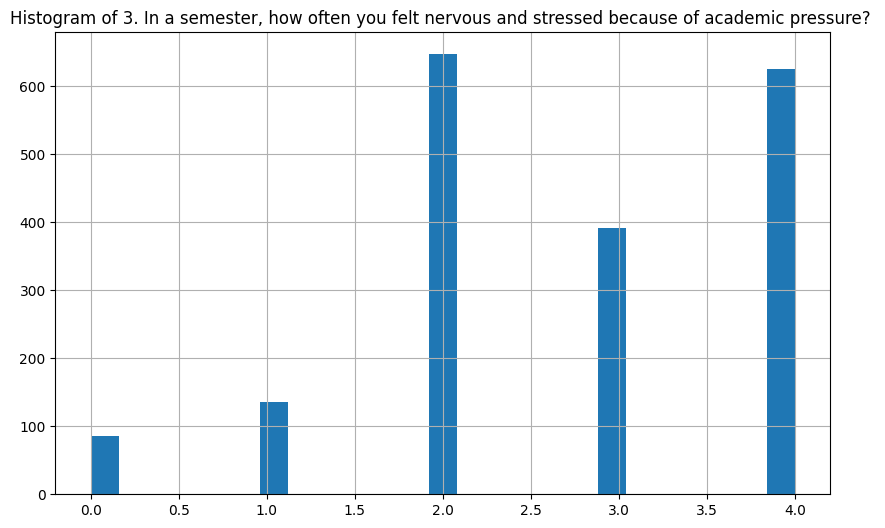

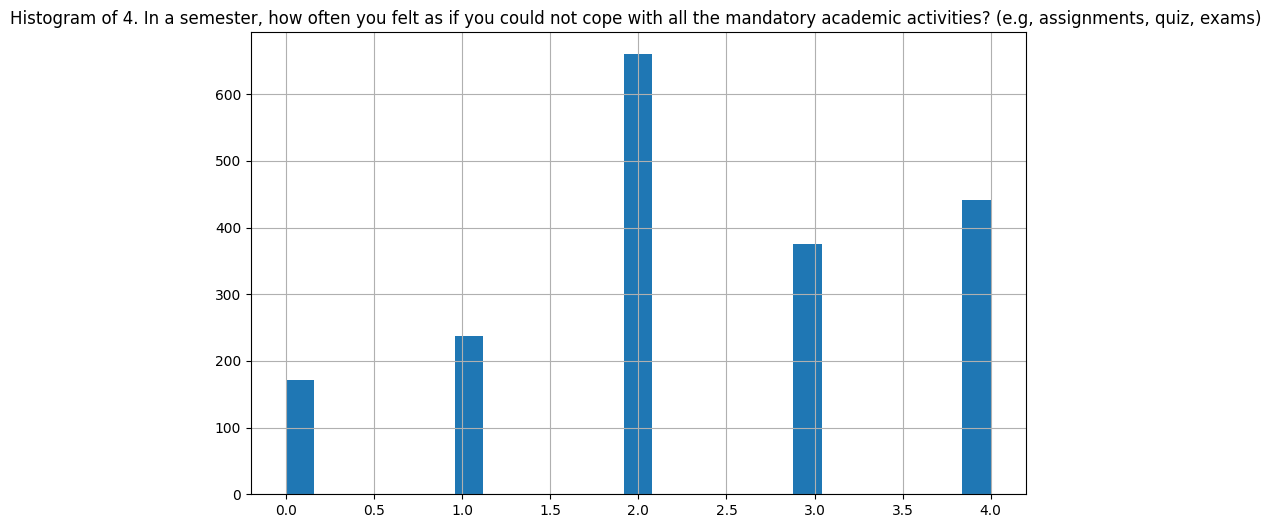

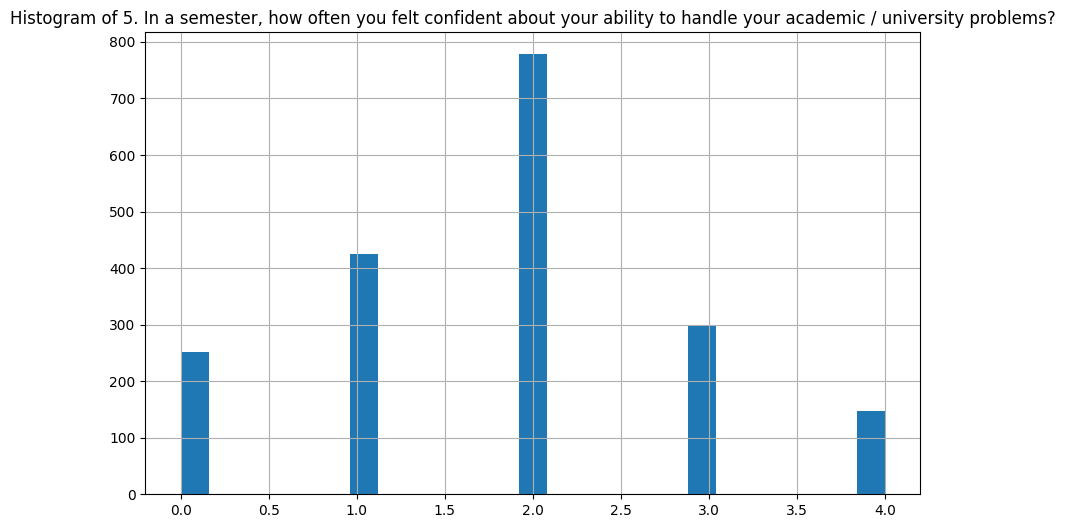

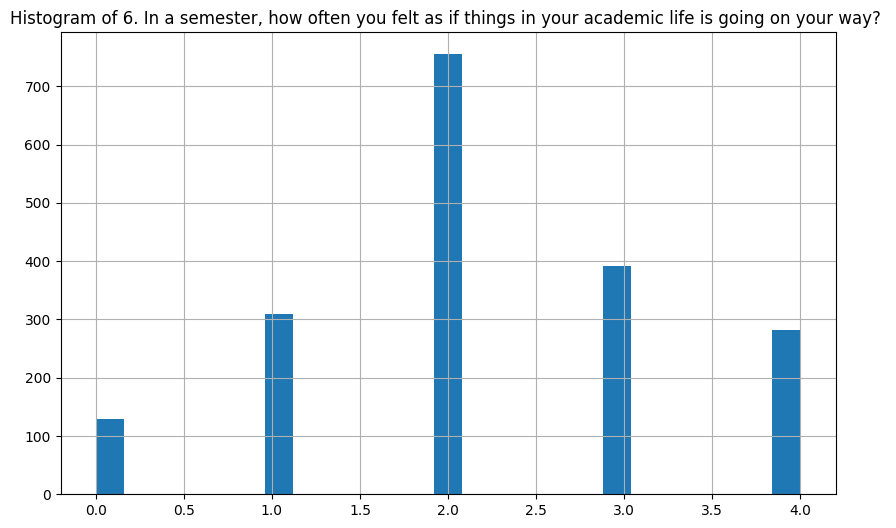

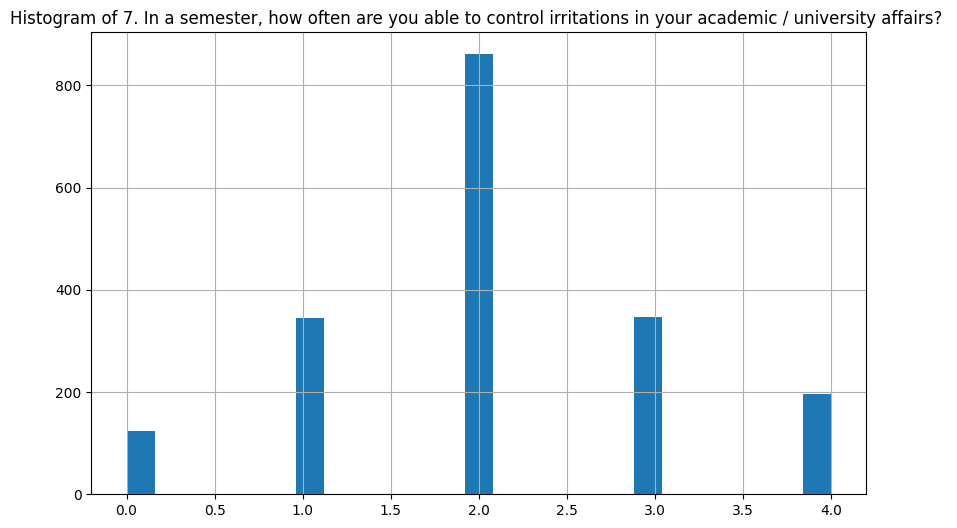

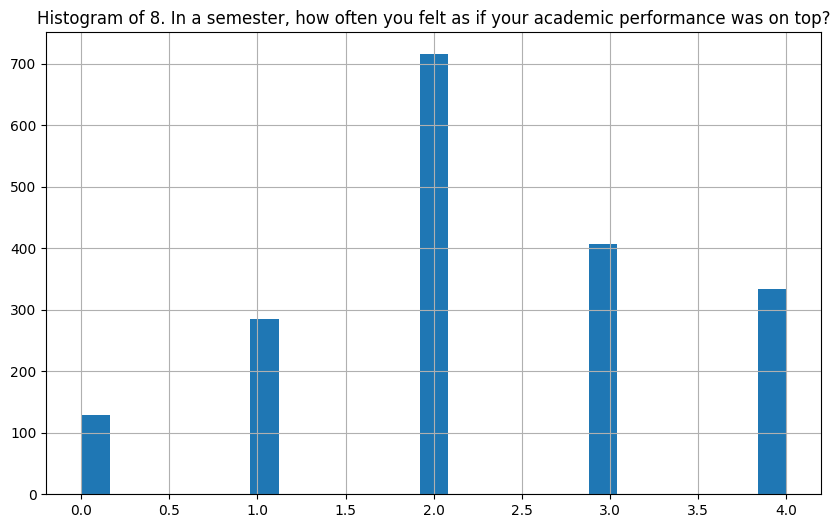

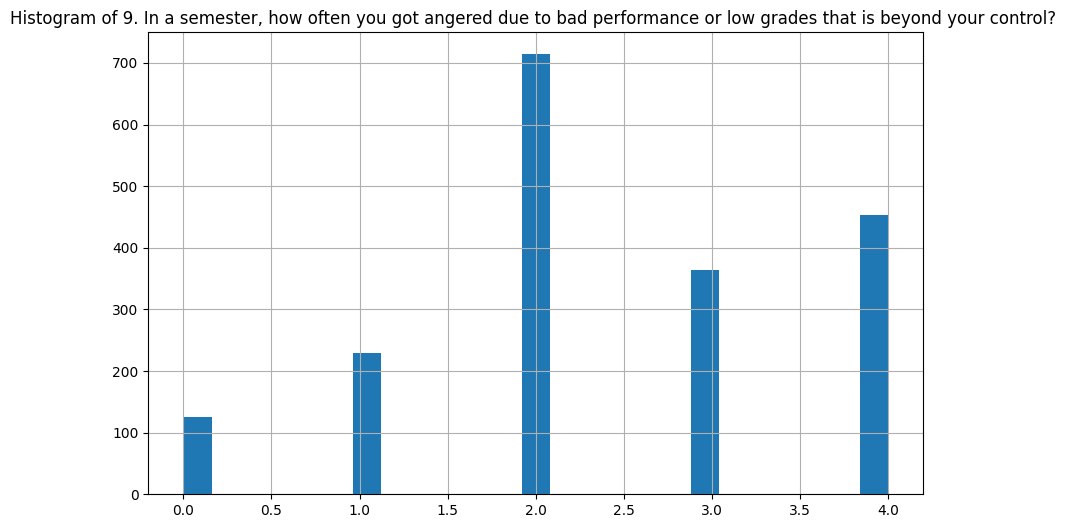

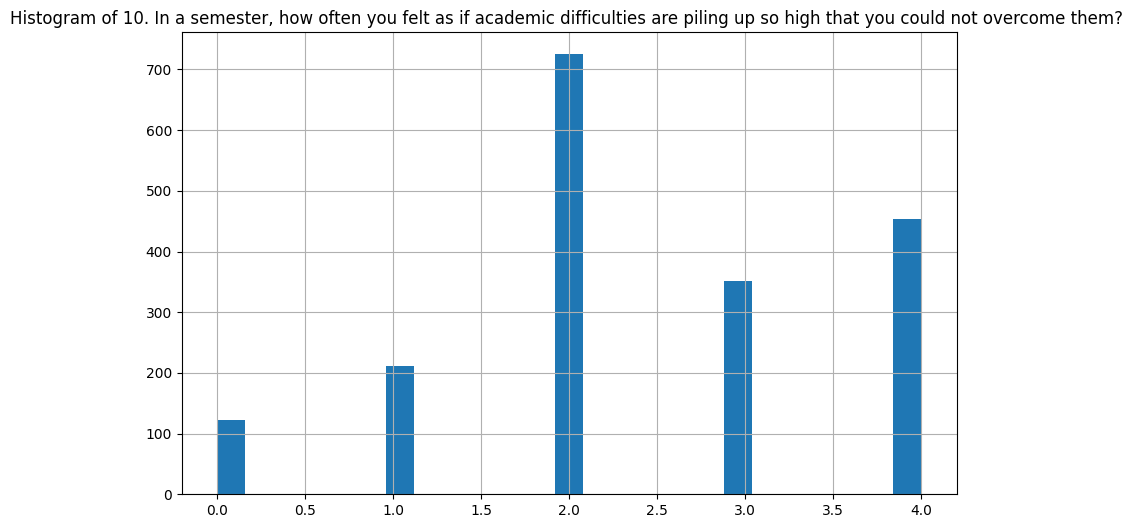

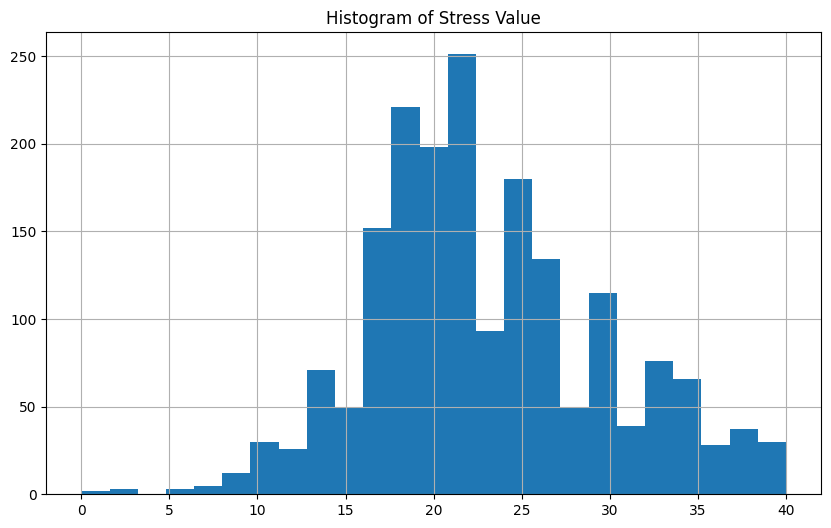

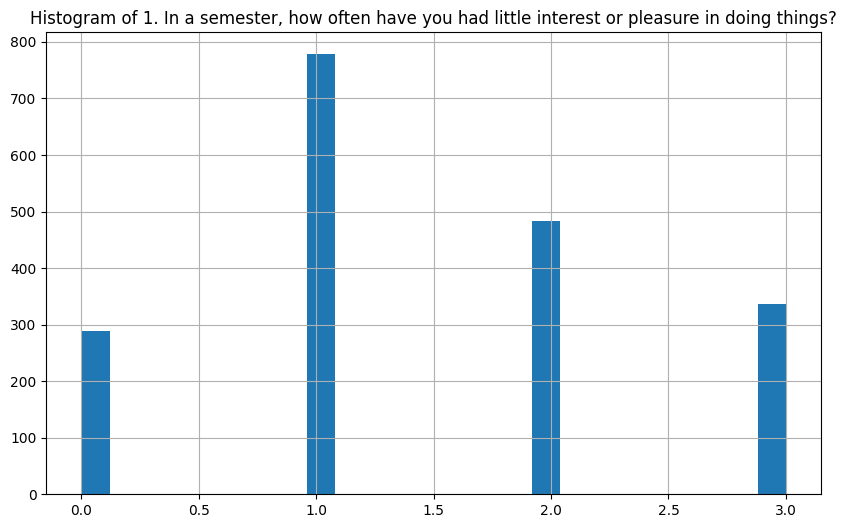

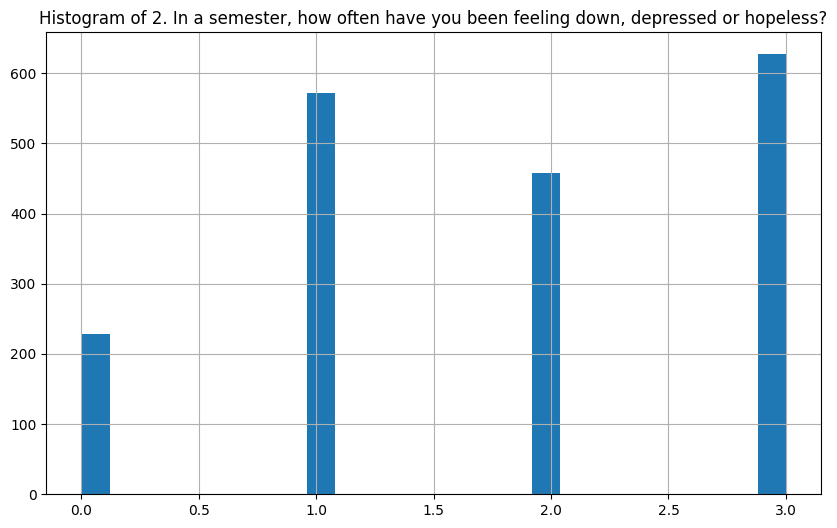

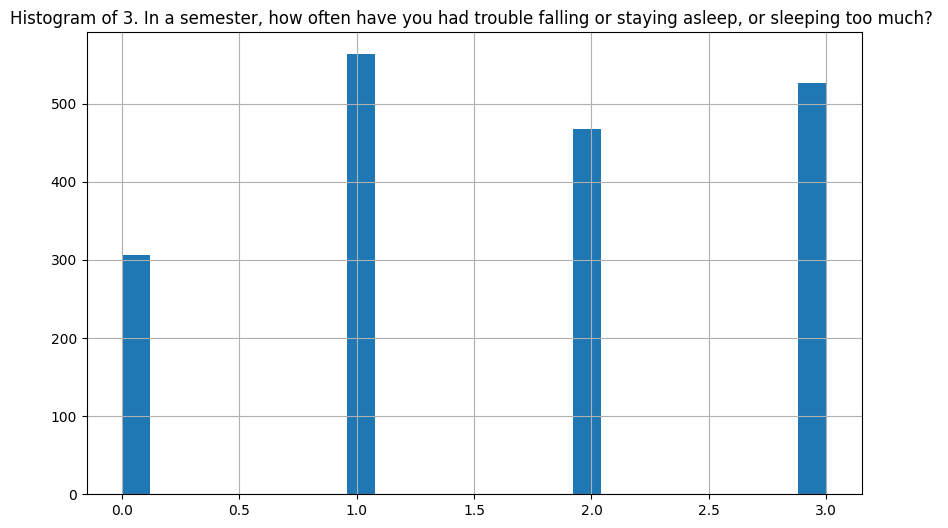

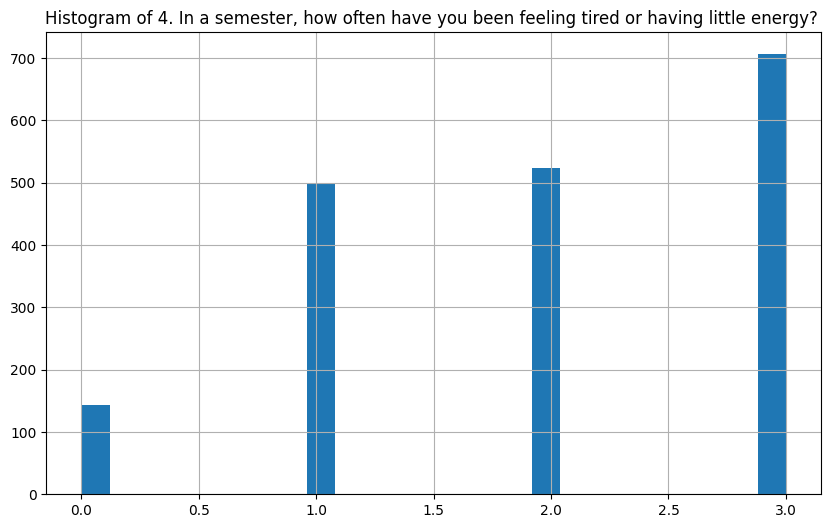

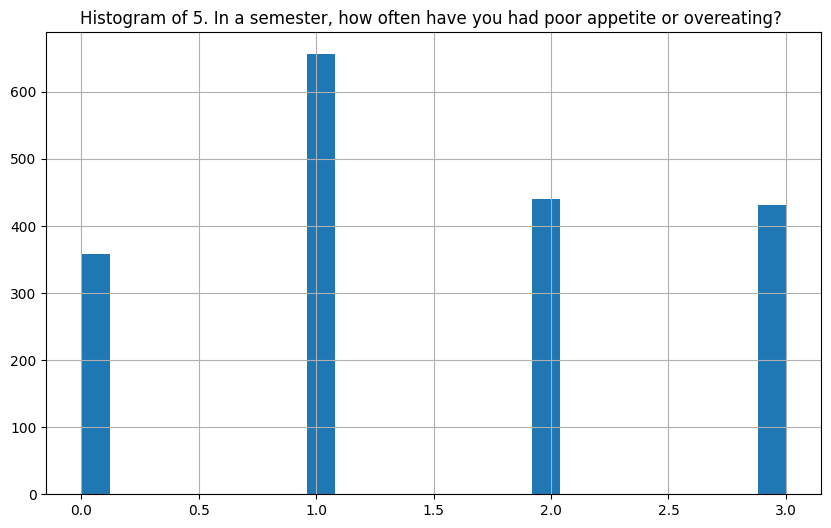

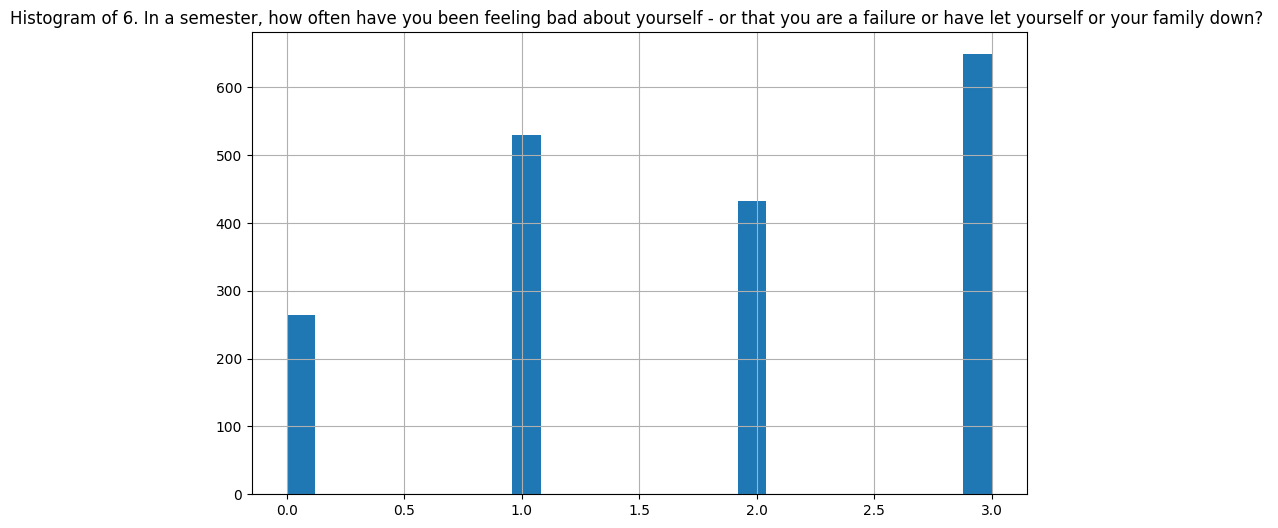

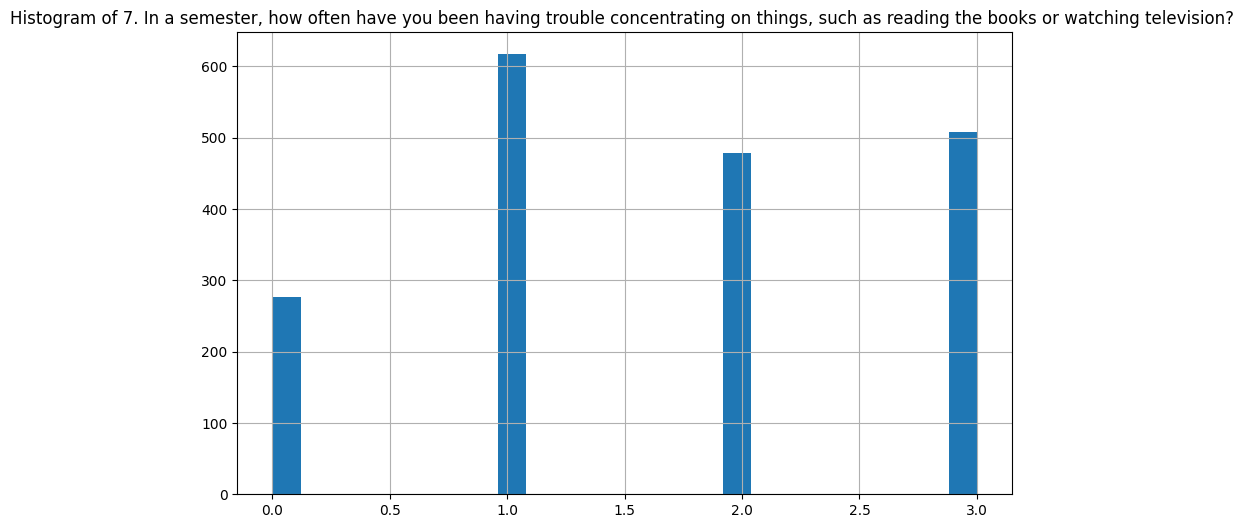

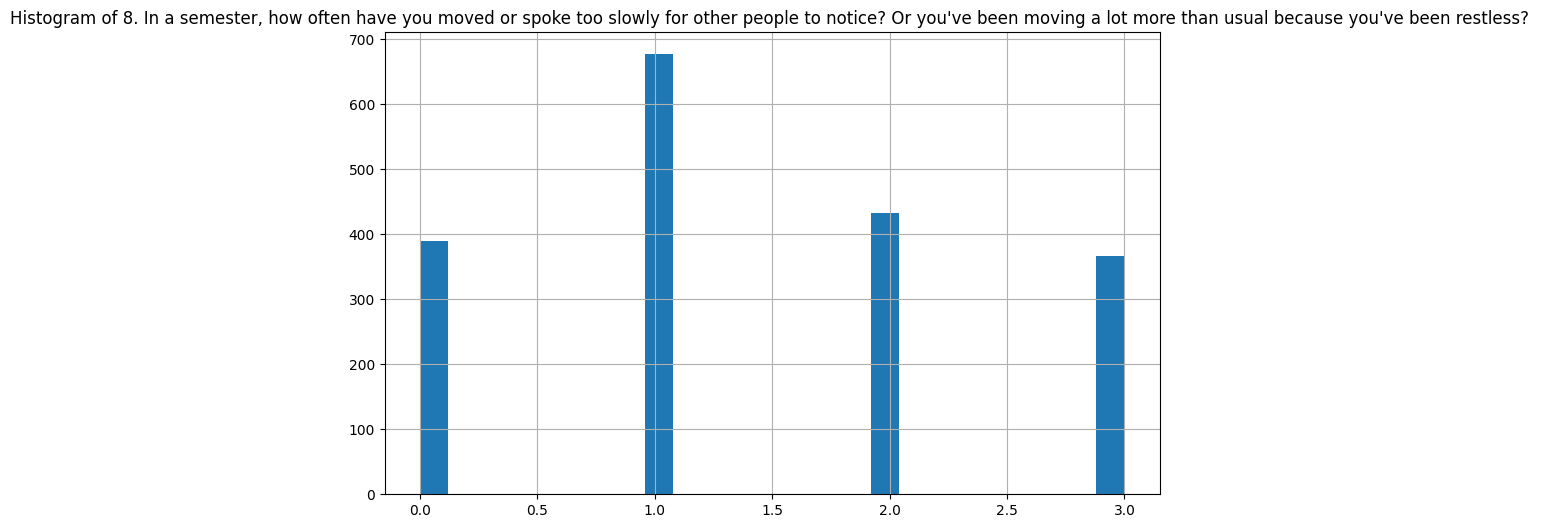

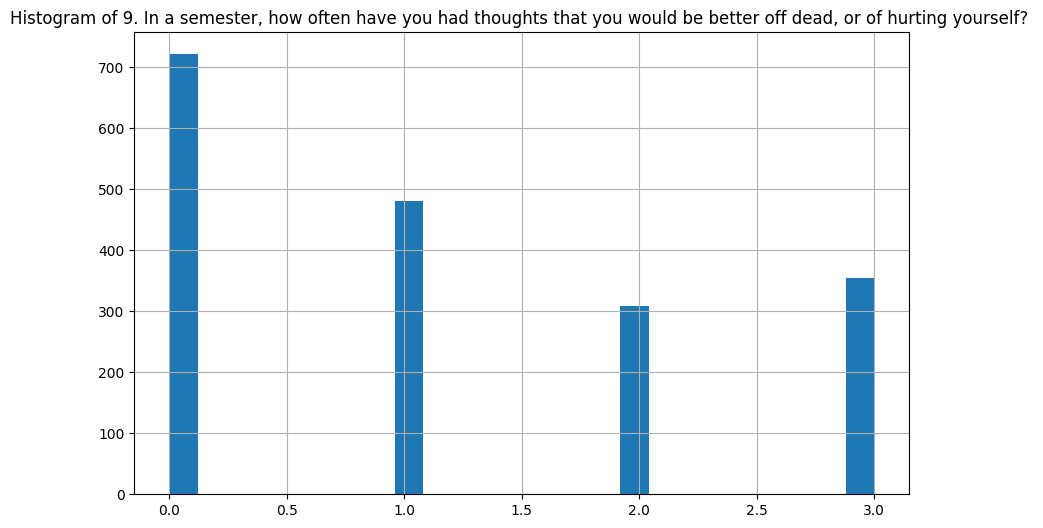

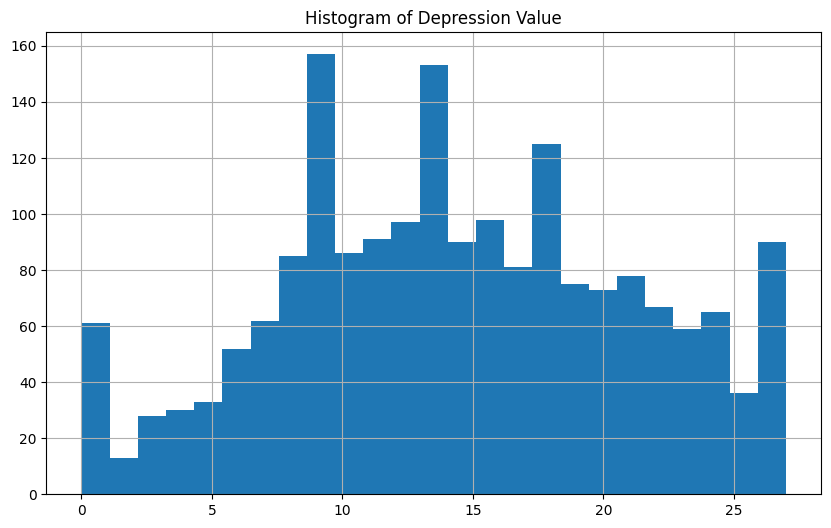

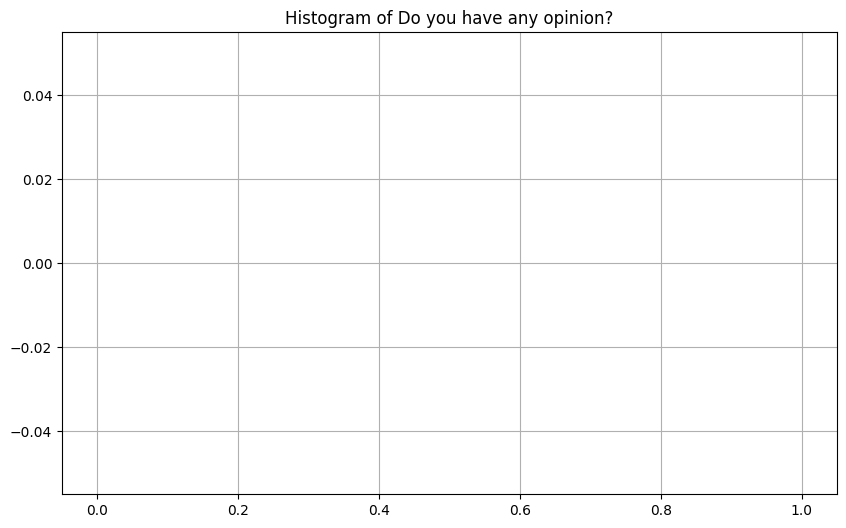

In [ ]:
for column in numerical_data.columns:
    plt.figure(figsize=(10, 6))
    numerical_data[column].hist(bins=25)
    plt.title(f'Histogram of {column}')
    plt.show()

In [ ]:
df = df.drop(['Do you have any opinion?'], axis = 1)
df.shape

(1977, 37)

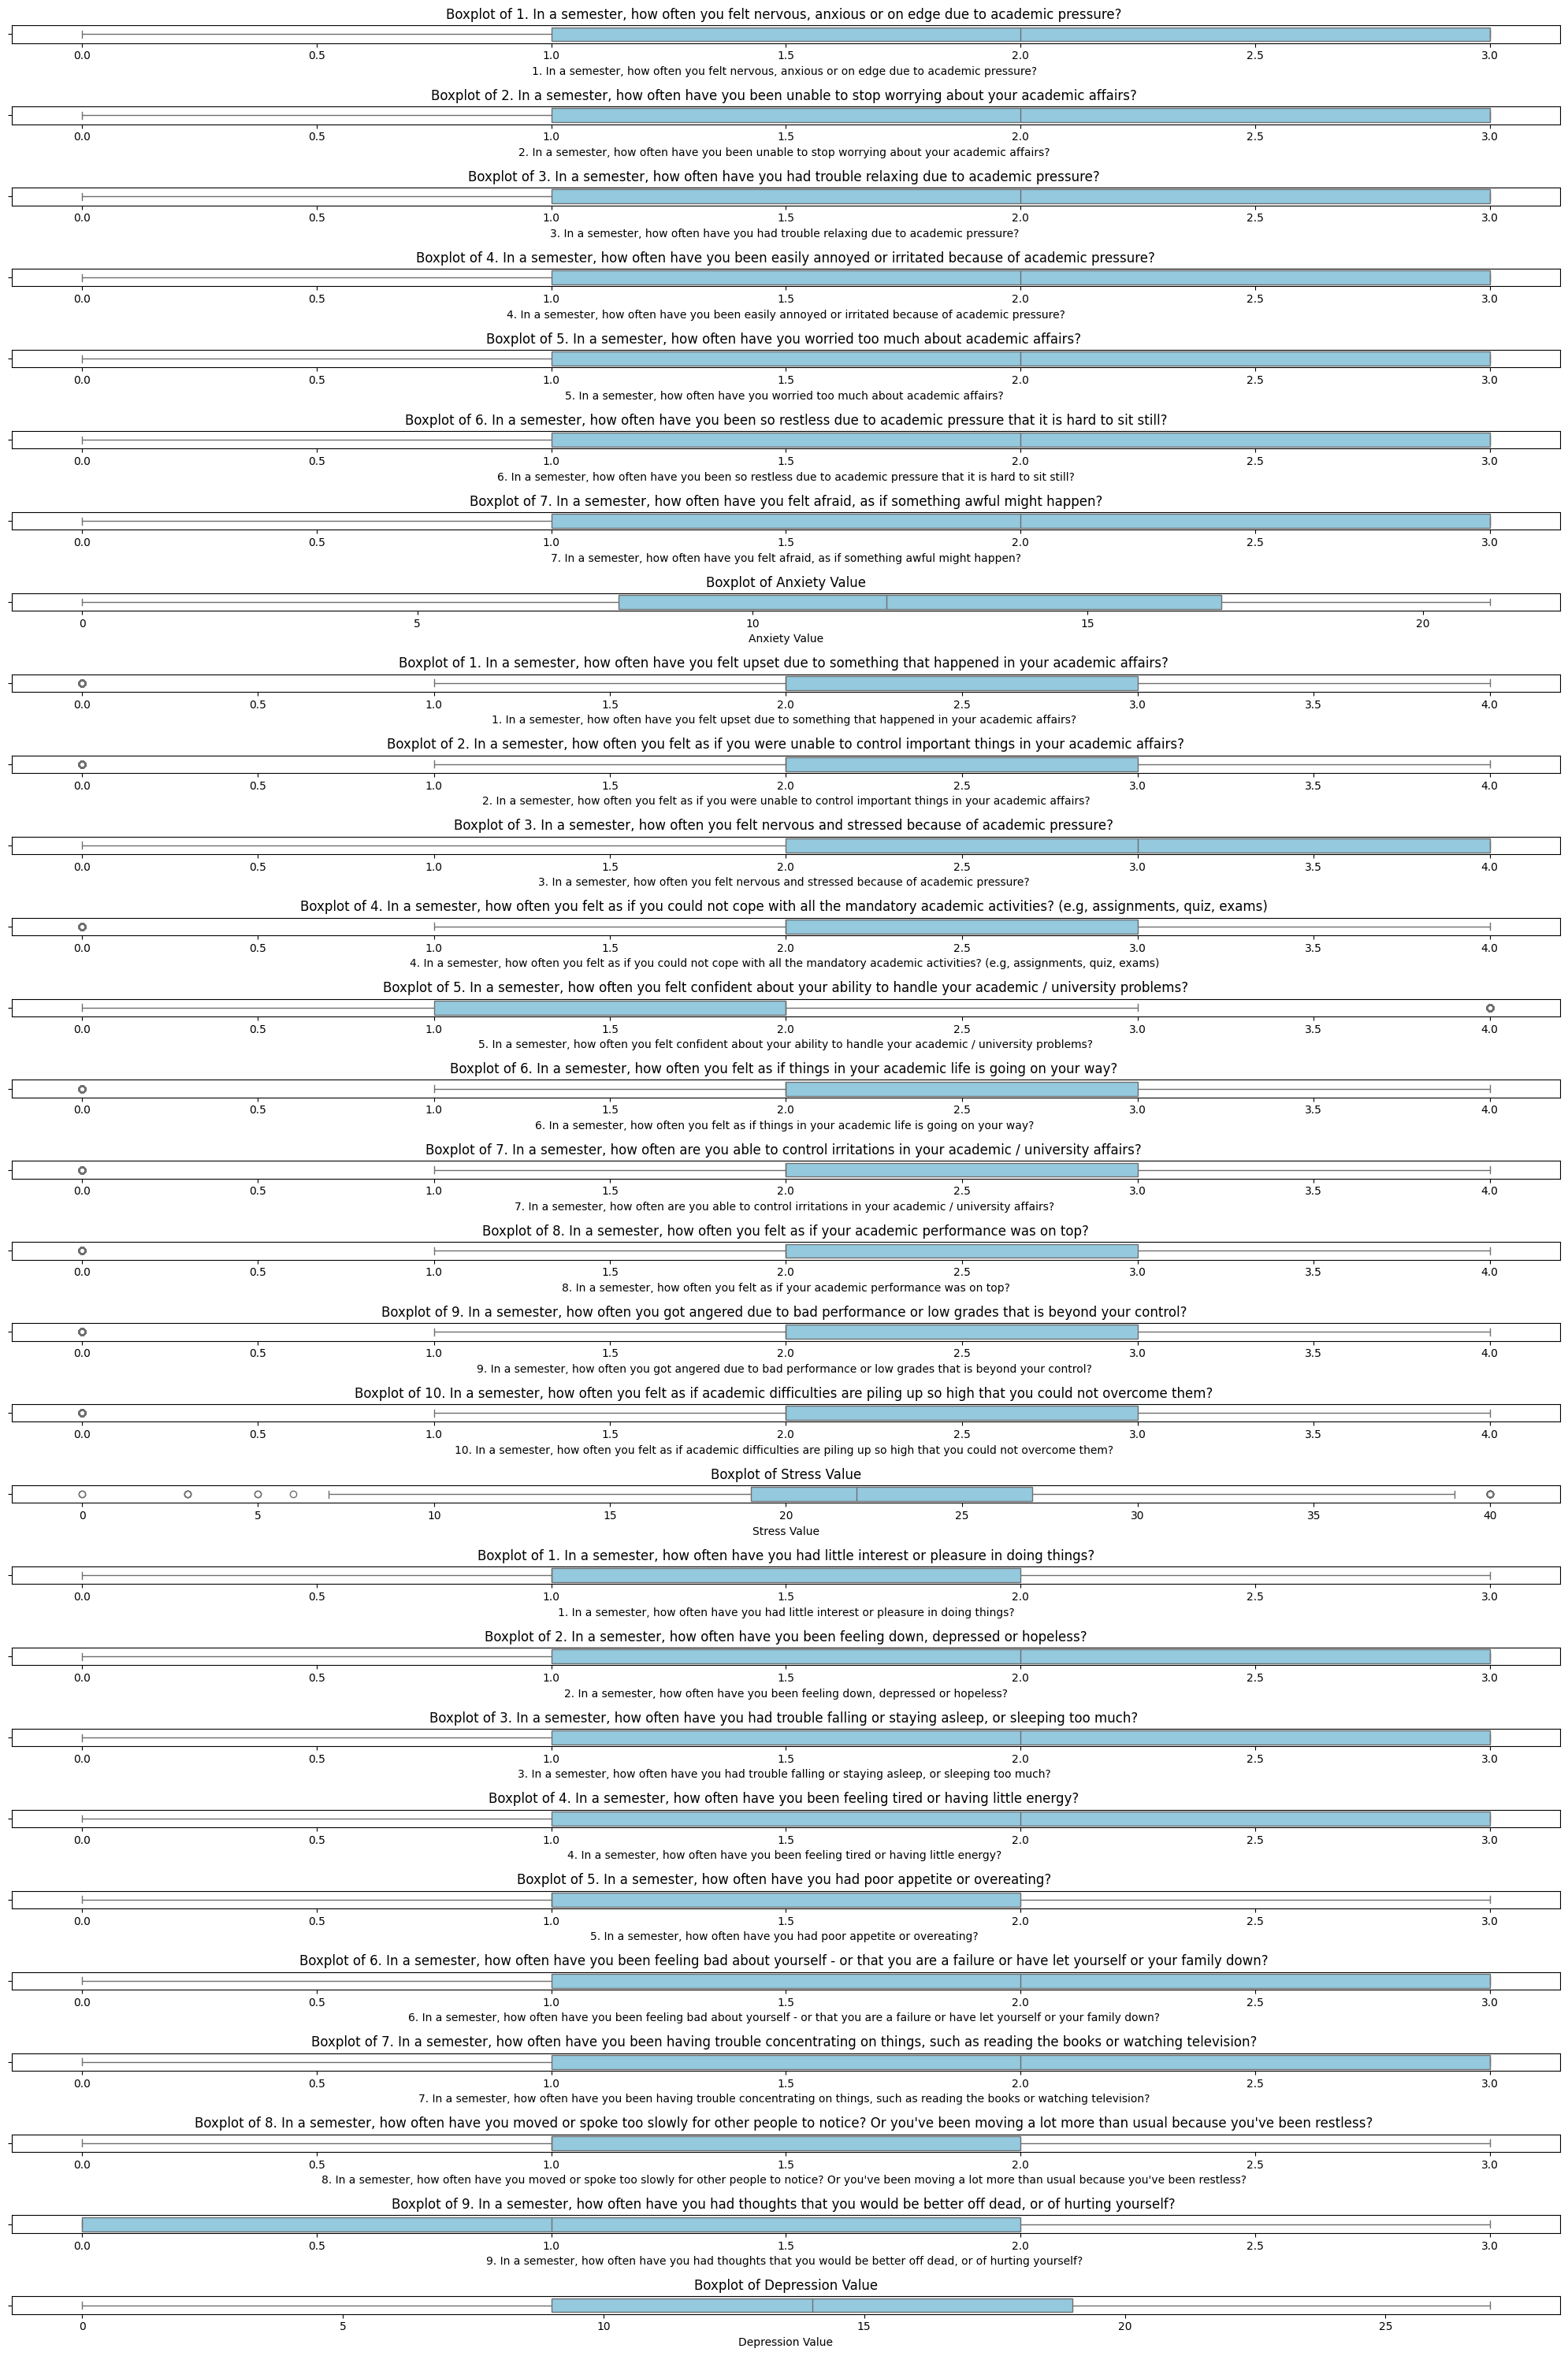

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

In [ ]:
numerical_data.nunique()

,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",4
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",4
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",4
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",4
"5. In a semester, how often have you worried too much about academic affairs?",4
"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?",4
"7. In a semester, how often have you felt afraid, as if something awful might happen?",4
Anxiety Value,22
"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?",5
"2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",5


In [ ]:
numerical_data.isnull().sum()

,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",98
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",82
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",89
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",103
"5. In a semester, how often have you worried too much about academic affairs?",88
"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?",99
"7. In a semester, how often have you felt afraid, as if something awful might happen?",89
Anxiety Value,95
"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?",99
"2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",106


In [ ]:
unique_counts=categorical_data.nunique()
print(unique_counts)

1. Age                                                            5
2. Gender                                                         3
5. Academic Year                                                  5
6. Current CGPA                                                   6
7. Did you receive a waiver or scholarship at your university?    2
Anxiety Label                                                     4
Stress Label                                                      3
Depression Label                                                  6
dtype: int64


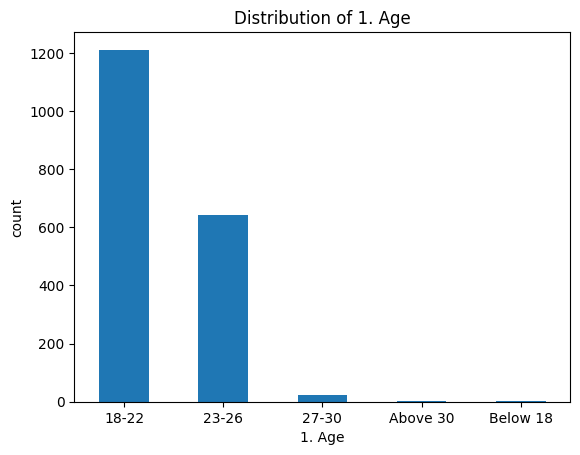

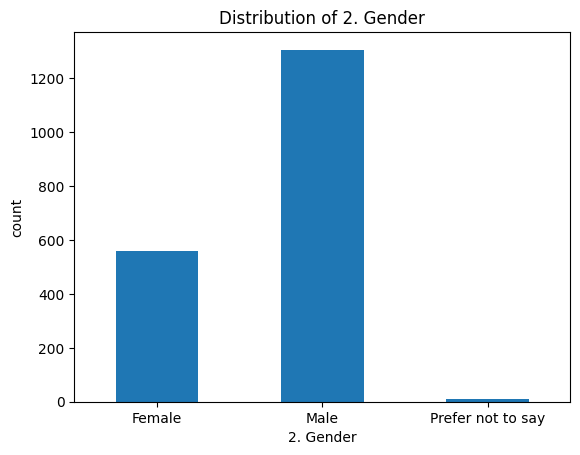

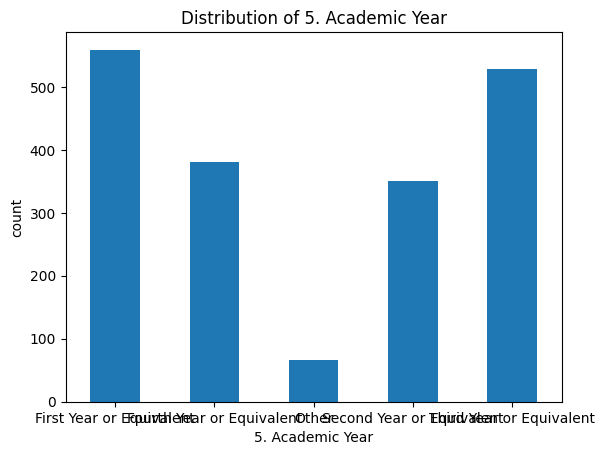

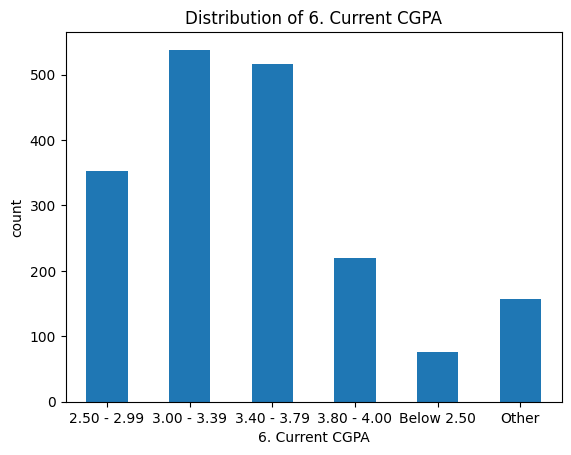

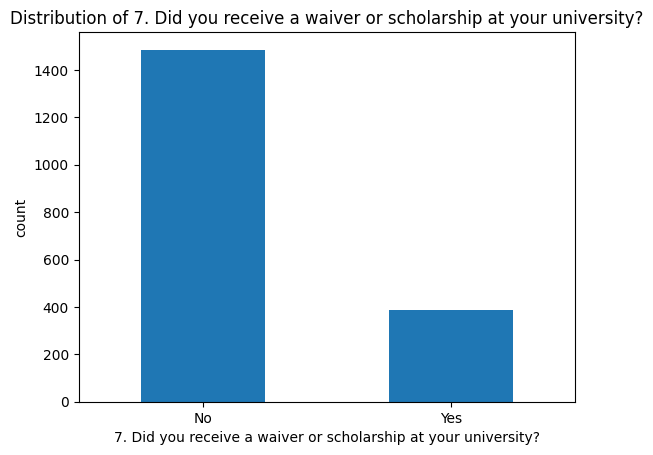

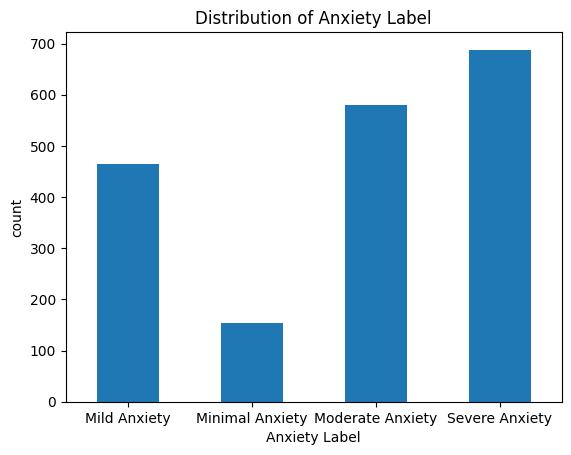

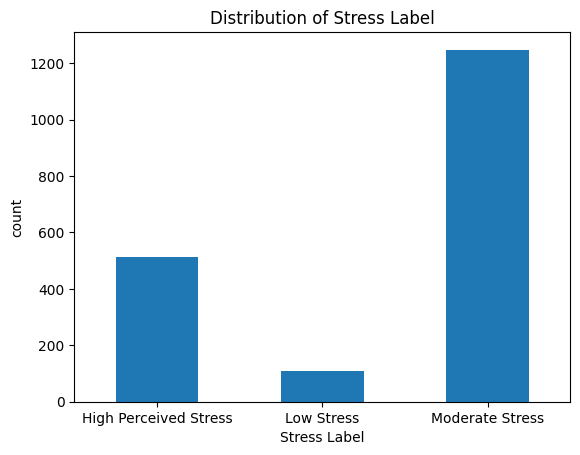

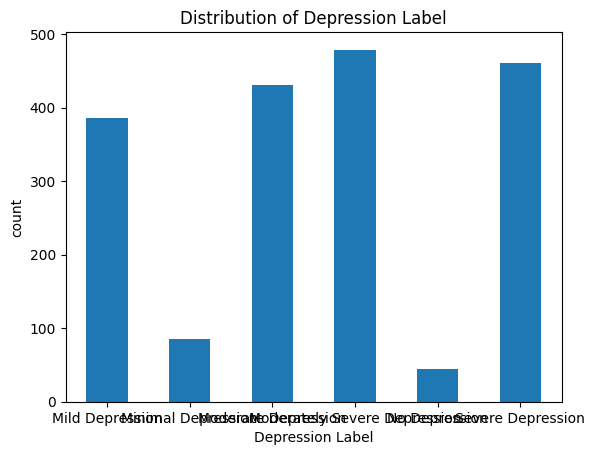

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

In [ ]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?","2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Do you have any opinion?
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",1.000000,0.495997,0.512894,0.633039,0.647660,0.581691,0.600727,0.805310,0.492908,0.507932,...,0.591023,0.429316,0.505350,0.405535,0.550936,0.476168,0.420567,0.422043,0.622223,NaN
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",0.495997,1.000000,0.468090,0.473379,0.506934,0.441339,0.449522,0.702834,0.344912,0.367551,...,0.427497,0.365461,0.390109,0.353487,0.409286,0.381718,0.317583,0.286236,0.486143,NaN
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0.512894,0.468090,1.000000,0.564183,0.515250,0.519029,0.511842,0.738454,0.376892,0.406769,...,0.496278,0.437914,0.473175,0.382926,0.434144,0.437537,0.369453,0.325551,0.561852,NaN
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",0.633039,0.473379,0.564183,1.000000,0.696707,0.595459,0.603289,0.821856,0.460267,0.487695,...,0.587851,0.435632,0.509340,0.419431,0.557773,0.500121,0.438329,0.427229,0.644826,NaN
"5. In a semester, how often have you worried too much about academic affairs?",0.647660,0.506934,0.515250,0.696707,1.000000,0.659286,0.666432,0.846825,0.434524,0.459245,...,0.618401,0.443660,0.519750,0.426033,0.572459,0.512217,0.436991,0.395143,0.647226,NaN
"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?",0.581691,0.441339,0.519029,0.595459,0.659286,1.000000,0.621870,0.797333,0.390863,0.412057,...,0.553158,0.426150,0.533562,0.416753,0.487274,0.450153,0.434297,0.390240,0.608423,NaN
"7. In a semester, how often have you felt afraid, as if something awful might happen?",0.600727,0.449522,0.511842,0.603289,0.666432,0.621870,1.000000,0.809880,0.450032,0.451379,...,0.632778,0.479923,0.517906,0.442049,0.582889,0.494762,0.477199,0.446549,0.665646,NaN
Anxiety Value,0.805310,0.702834,0.738454,0.821856,0.846825,0.797333,0.809880,1.000000,0.539465,0.559974,...,0.708059,0.547267,0.620799,0.514911,0.651188,0.593848,0.528151,0.485537,0.766166,NaN
"1. In a semester, how often have you felt upset due to something th

/tmp/ipython-input-3398861938.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # Adjust layout to prevent clipping


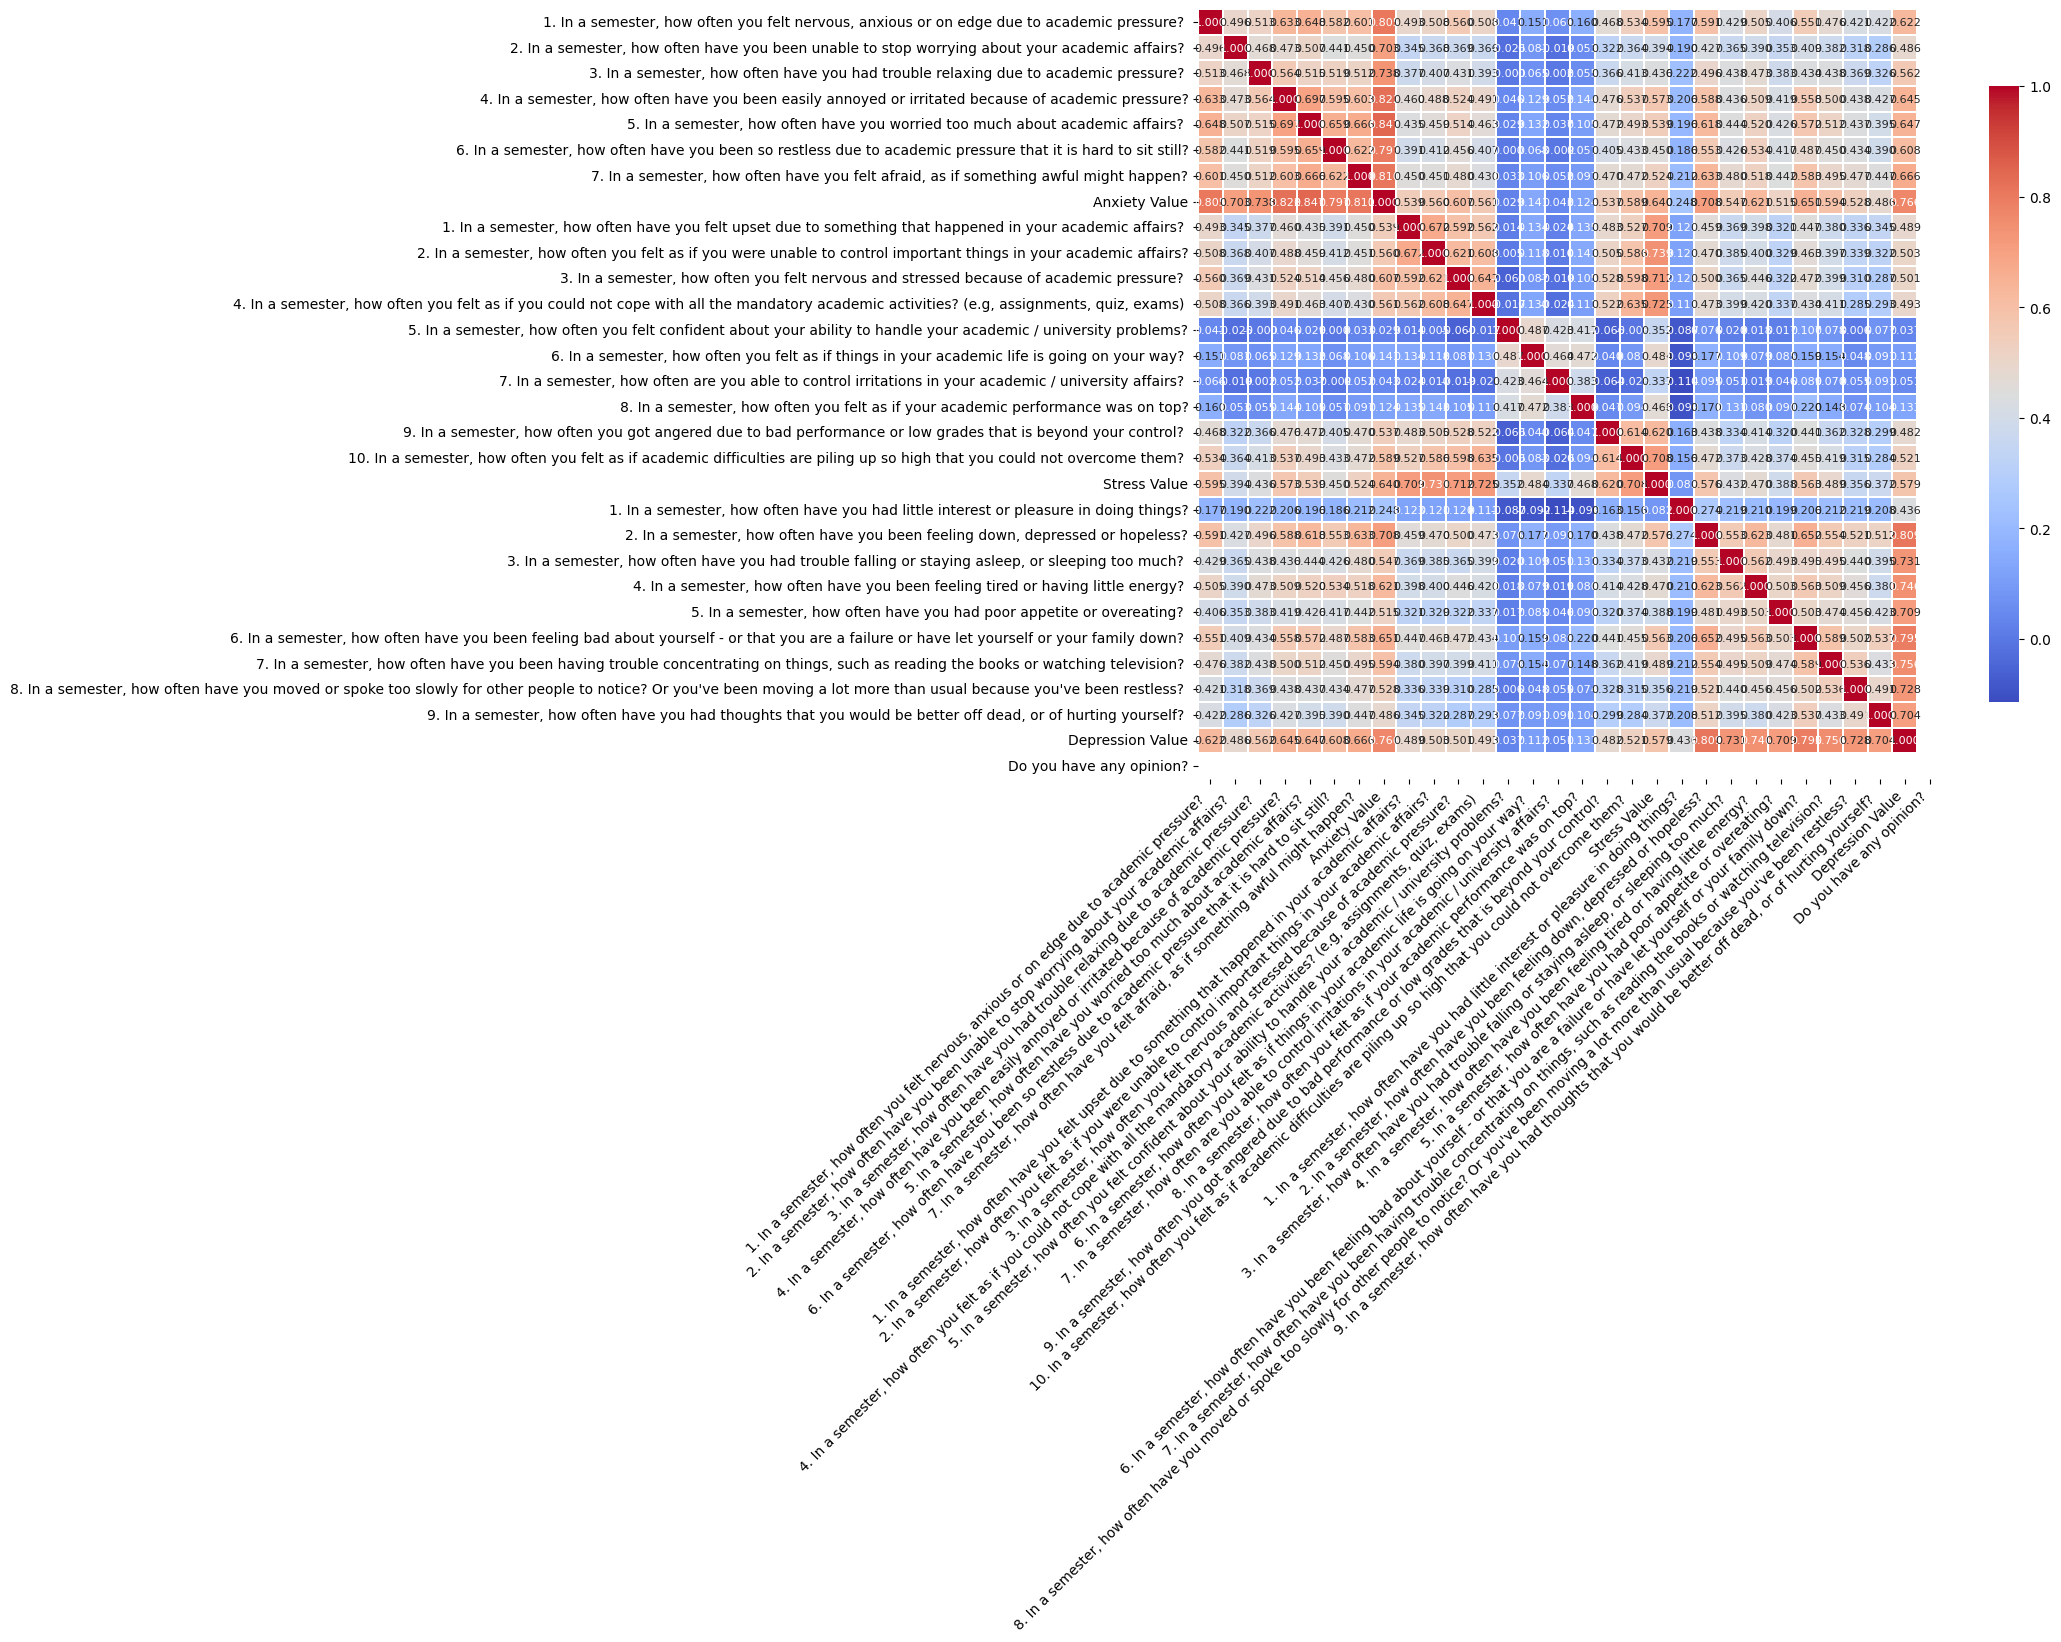

In [ ]:
plt.figure(figsize=(12, 10))

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.3, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})


plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Select only the numerical columns
numerical_data = df.select_dtypes(include=['int64', 'float64'])


corr = numerical_data.corr('pearson')[['Depression Value']].sort_values(by='Depression Value', ascending=False)


print(corr)


                                                    Depression Value
Depression Value                                            1.000000
2. In a semester, how often have you been feeli...          0.809325
6. In a semester, how often have you been feeli...          0.794672
Anxiety Value                                               0.766166
7. In a semester, how often have you been havin...          0.755929
4. In a semester, how often have you been feeli...          0.745523
3. In a semester, how often have you had troubl...          0.730556
8. In a semester, how often have you moved or s...          0.727761
5. In a semester, how often have you had poor a...          0.709236
9. In a semester, how often have you had though...          0.704228
7. In a semester, how often have you felt afrai...          0.665646
5. In a semester, how often have you worried to...          0.647226
4. In a semester, how often have you been easil...          0.644826
1. In a semester, how often you fe

In [ ]:

class_counts = df['Depression Label'].value_counts()


columns = ['outcome', 'count', 'percentage']
outcome = class_counts.index.tolist()
count = class_counts.tolist()
total_count = len(df)

# Calculate the percentage for each class
percentage = [(count_val / total_count) * 100 for count_val in count]

# Create a dataframe for displaying imbalance
imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)), columns=columns)
print(imbalance_df)


                        outcome  count  percentage
0  Moderately Severe Depression    479   24.228629
1             Severe Depression    461   23.318159
2           Moderate Depression    431   21.800708
3               Mild Depression    386   19.524532
4            Minimal Depression     86    4.350025
5                 No Depression     44    2.225594


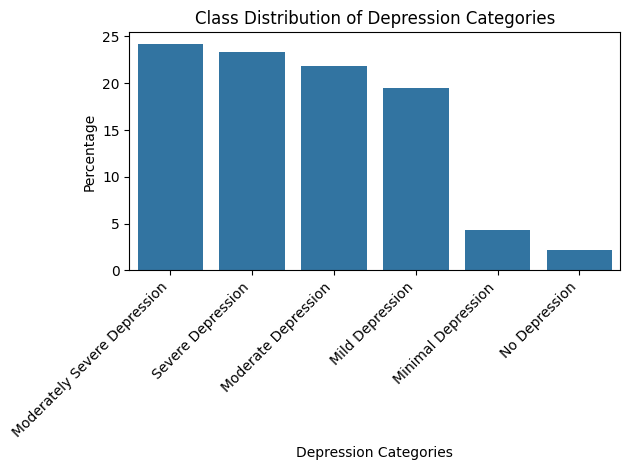

In [ ]:
sns.barplot(data=imbalance_df, x='outcome', y='percentage', order=imbalance_df['outcome'])
plt.xticks(rotation=45, ha='right')  # Rotate the labels for better readability
plt.xlabel('Depression Categories')
plt.ylabel('Percentage')
plt.title('Class Distribution of Depression Categories')
plt.tight_layout()
plt.show()

#Data Preprocessing

In [ ]:
#handling null values
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining nulls:", df.isnull().sum().sum())


Remaining nulls: 0


In [ ]:
#Encode Data (Label Encoding)

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   1. Age  2. Gender  5. Academic Year  6. Current CGPA  \
0       0          0                 1                0   
1       0          1                 0                3   
2       0          1                 0                1   
3       0          1                 0                2   
4       0          1                 0                2   

   7. Did you receive a waiver or scholarship at your university?  \
0                                                  0                
1                                                  0                
2                                                  0                
3                                                  0                
4                                                  0                

   1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?   \
0                                                1.0                                             
1                                 

In [ ]:
#Splitting and Scaling.

# We drop 'Depression Label' (the text answer) and 'Depression Value' (the score)
# because those ARE the answers, and the AI shouldn't see them as input.

X = df.drop(['Depression Label', 'Depression Value'], axis=1)
y = df['Depression Label']

# 2. Scale Features Make all numbers between 0 and 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape} (80%)")
print(f"Testing Data: {X_test.shape} (20%)")

Training Data: (1581, 35) (80%)
Testing Data: (396, 35) (20%)


###Model training & testing (Supervised)

In [ ]:
# 1. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

In [ ]:
# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

In [ ]:
# 3. Logistic Regression (The new 4th model)
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

In [ ]:
# 4. Neural Network (MLP)
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
acc_nn = accuracy_score(y_test, y_pred_nn)

In [ ]:
# Print Results
print(f"KNN Accuracy:                 {acc_knn*100:.2f}%")
print(f"Decision Tree Accuracy:       {acc_dt*100:.2f}%")
print(f"Logistic Regression Accuracy: {acc_lr*100:.2f}%")
print(f"Neural Network Accuracy:      {acc_nn*100:.2f}%")

KNN Accuracy:                 67.17%
Decision Tree Accuracy:       61.87%
Logistic Regression Accuracy: 81.31%
Neural Network Accuracy:      81.82%


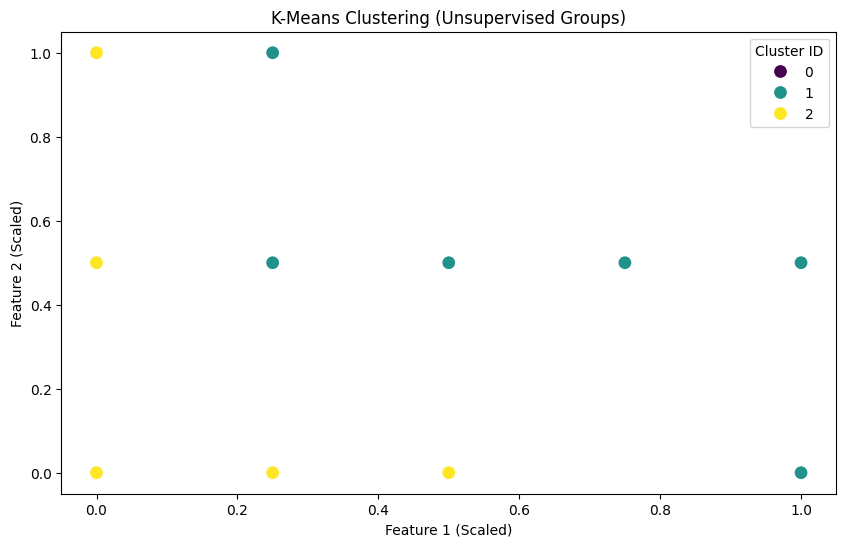

In [ ]:
#Unsupervised Learning (K-Means)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Treating problem as unsupervised (ignore labels)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# clusters
plt.figure(figsize=(10, 6))
#first 2 features just to visualize the grouping
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=clusters, palette='viridis', s=100)
plt.title('K-Means Clustering (Unsupervised Groups)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend(title='Cluster ID')
plt.show()


#We apply Unsupervised Learning (K-Means) to see if the students naturally group into clusters without using the labels. We chose K=3 to see if they group into Low, Medium, and High depression levels.

###**Comparison analysis**

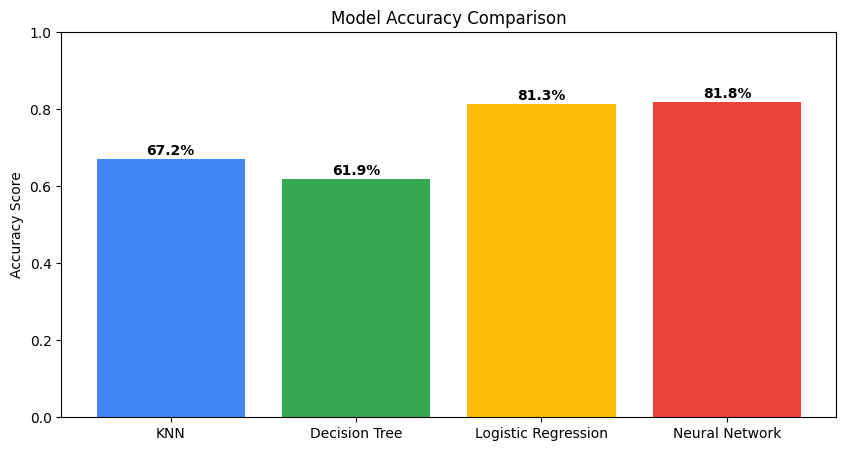

In [ ]:
#Accuracy Bar Chart
models = {
    'KNN': (knn, y_pred_knn),
    'Decision Tree': (dt, y_pred_dt),
    'Logistic Regression': (lr, y_pred_lr),
    'Neural Network': (nn, y_pred_nn)
}

accuracies = {
    'KNN': acc_knn,
    'Decision Tree': acc_dt,
    'Logistic Regression': acc_lr,
    'Neural Network': acc_nn
}


plt.figure(figsize=(10, 5))
plt.bar(accuracies.keys(), accuracies.values(), color=['#4285F4', '#34A853', '#FBBC05', '#EA4335'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', fontweight='bold')
plt.show()

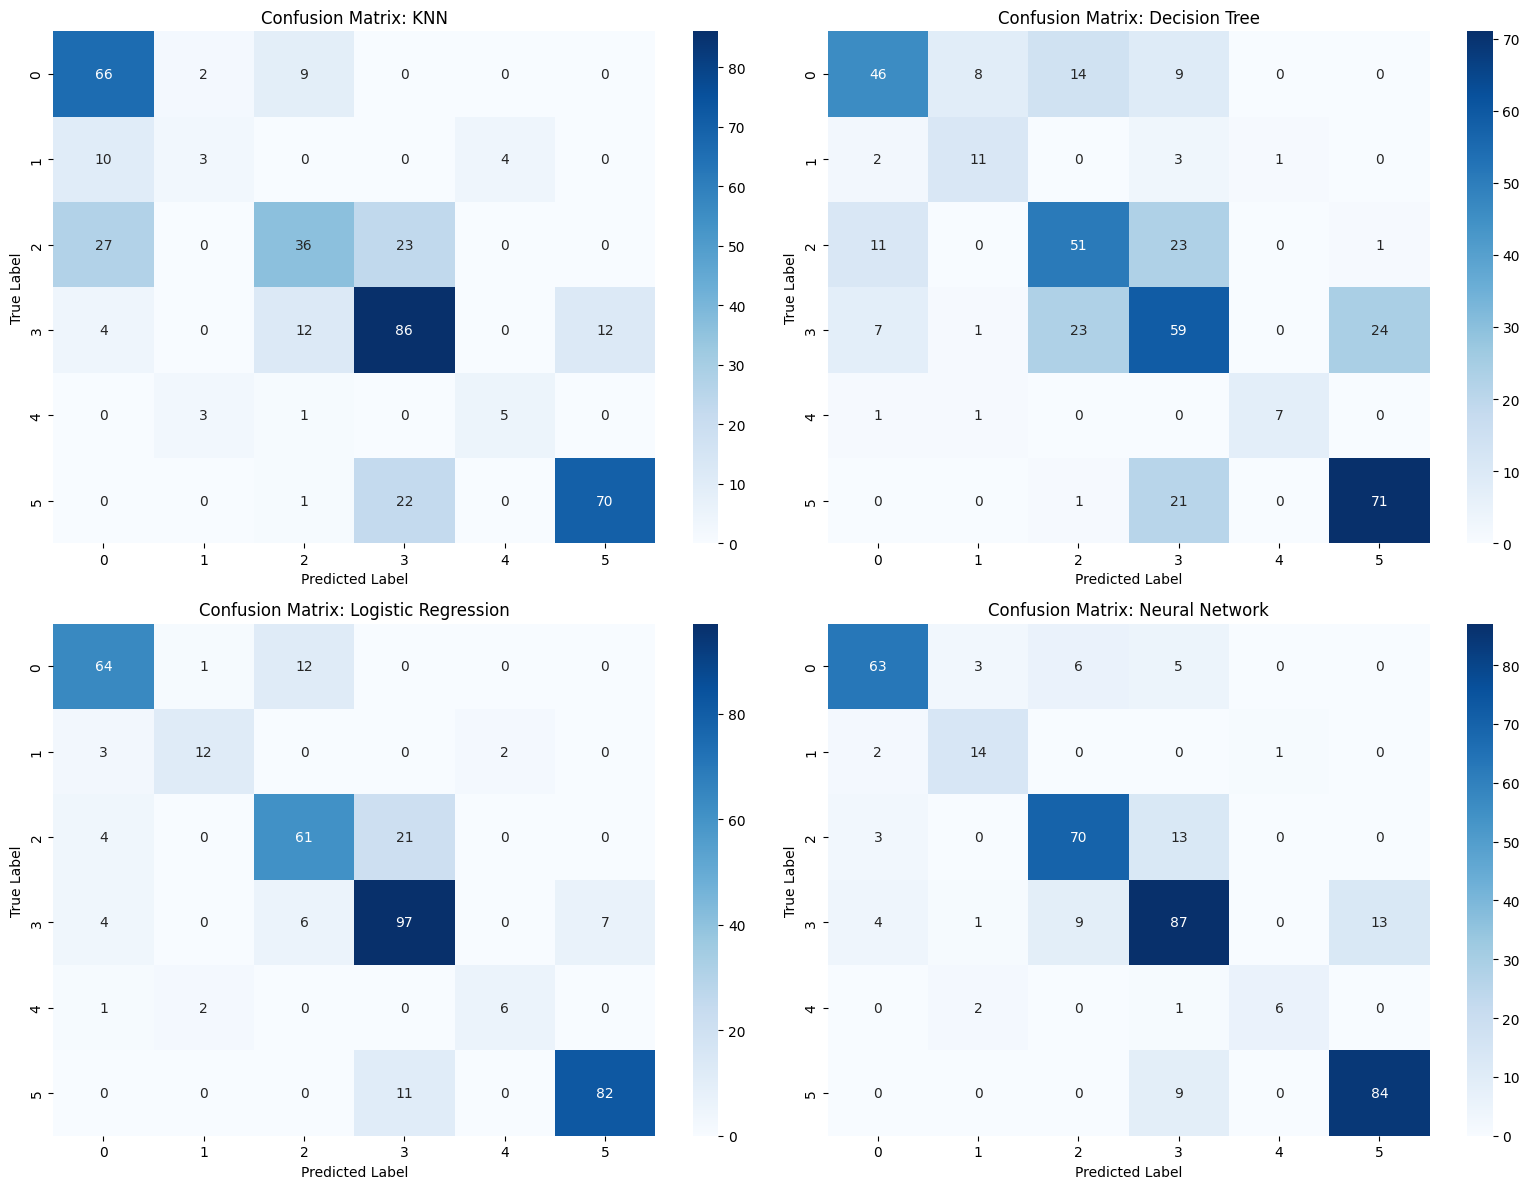

In [ ]:
# Confusion Matrices

plt.figure(figsize=(16, 12))
for i, (name, (model, y_pred)) in enumerate(models.items()):
    plt.subplot(2, 2, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
# Precision, Recall & Classification Report

for name, (model, y_pred) in models.items():
    print(f"\n{'='*40}")
    print(f"REPORT: {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))


REPORT: KNN
              precision    recall  f1-score   support

           0       0.62      0.86      0.72        77
           1       0.38      0.18      0.24        17
           2       0.61      0.42      0.50        86
           3       0.66      0.75      0.70       114
           4       0.56      0.56      0.56         9
           5       0.85      0.75      0.80        93

    accuracy                           0.67       396
   macro avg       0.61      0.59      0.59       396
weighted avg       0.67      0.67      0.66       396


REPORT: Decision Tree
              precision    recall  f1-score   support

           0       0.69      0.60      0.64        77
           1       0.52      0.65      0.58        17
           2       0.57      0.59      0.58        86
           3       0.51      0.52      0.52       114
           4       0.88      0.78      0.82         9
           5       0.74      0.76      0.75        93

    accuracy                           0.

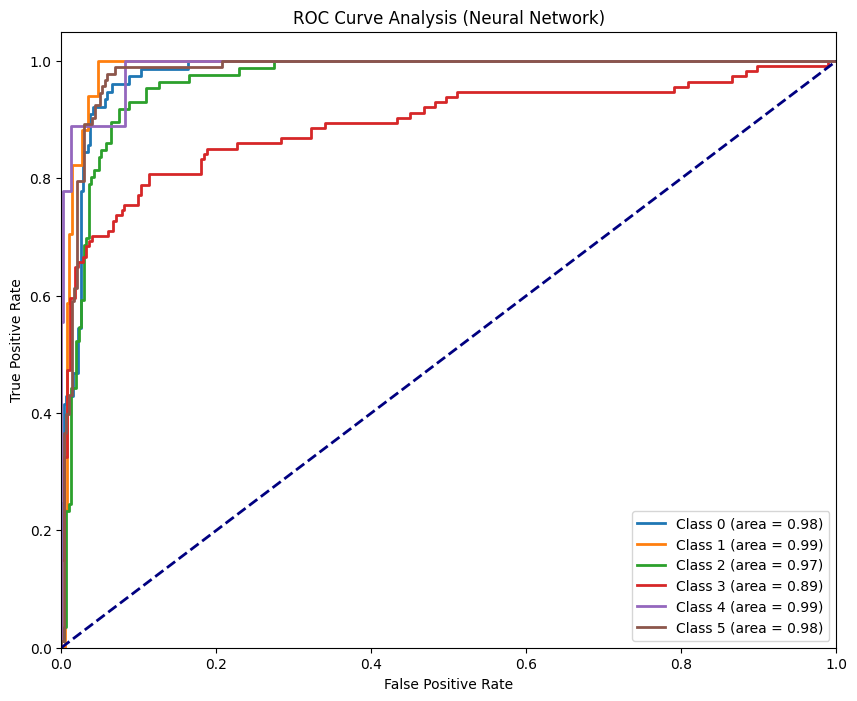

In [ ]:
# ROC Curve & AUC (for Neural Network)

# Since this is multi-class, we plot ROC for each class separately


y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Get probabilities
y_score = nn.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Analysis (Neural Network)')
plt.legend(loc="lower right")
plt.show()

#Since this is a multi-class problem, we plotted the ROC curve for 'Severe Depression' (Class 0) vs. All Other Classes to demonstrate the model's ability to identify the most critical cases.